# **Deepfake Project**

In [1]:
# import kagglehub

# # kaggle_api = KGAT_8eb0727ee6d566add6db98054cc75b1f
# kagglehub.login()

In [2]:
# kagglehub.competition_download(
#     "ml-intensive-yandex-academy-spring-2026",
#     output_dir="./data"
# )

# **IMPORTS MODULE**

In [3]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
from torch import nn
from math import ceil
import shutil
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision.transforms import transforms 
from torchmetrics import F1Score
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [4]:
# !nvidia-smi
# !nvcc --version

In [5]:
SEED = 42

def set_seed(
        seed: int
):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

# **DATASET MODULE**

In [6]:
def dir_length(
        path: str
) -> int:
    abs_path = os.path.abspath(path)
    return len(os.listdir(abs_path))


class CustomDataset(Dataset):
    def __init__(
            self,
            data: list[tuple],
            _transform = None
    ):
        self.data = data
        self._transform = _transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(
            self,
            index: int
    ): 
        image = Image.open(self.data[index][0]).convert("RGB")
        label = self.data[index][1]
        
        if self._transform:
            image = self._transform(image)
        
        return image, label
    

def rebalance_dataset(
        _image_size : tuple[int],
        csv_file_path: str,
        new_csv_file_path: str,
        train_dir_path: str,
        new_dir_path: str
):
    dataframe = pd.read_csv(
        csv_file_path,
        names=["id", "label"]
    )
    csv_data = {
        "id": tuple(dataframe["id"]),
        "label": tuple(dataframe["label"])
    }
    all_length = len(dataframe)
    dataframe1 = dataframe[dataframe["label"] == 1]
    length_dataframe1 = len(dataframe1)
    
    ratio = ceil(
        (all_length - length_dataframe1) / length_dataframe1
    )
    
    transform = transforms.Compose([
        transforms.RandomResizedCrop(
            _image_size,
            scale=(0.8, 1.),
            ratio=(0.75, 1.33)
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
            hue=0.05
        )
    ])
    
    if not os.path.exists(new_dir_path):
        os.mkdir(
            new_dir_path
        )
    
    for ind in dataframe["id"]:
        shutil.copyfile(
            src=os.path.join(train_dir_path, f"{ind}.jpg"),
            dst=os.path.join(new_dir_path, f"{ind}.jpg")
        )
    image_id = all_length

    new_data = {
        "id": [],
        "label": []
    }
    for standard_ind in dataframe1["id"]:
        standard_image = Image.open(
            os.path.join(train_dir_path, f"{standard_ind}.jpg")
        ).convert("RGB")
        
        for _ in range(ratio - 1):
            converted_image: Image.Image = transform(standard_image)
            converted_image.save(
                os.path.join(new_dir_path, f"{image_id}.jpg")
            )
            new_data["id"].append(image_id)
            new_data["label"].append(1)
            
            image_id += 1
            
    csv_data["id"] += tuple(new_data["id"])
    csv_data["label"] += tuple(new_data["label"])
    
    new_df = pd.DataFrame(csv_data)
    new_df.to_csv(
        new_csv_file_path,
        header=False,
        index=False
    )
    print("New dataset was made.")


def load_all_data(
        root_dir: str,
        csv_path: str = None
):
    _data = []
    solutions_data = pd.read_csv(
        csv_path, names=["id", "label"]
    ) if csv_path else None
    length = dir_length(root_dir)
    for ind in range(length): # tqdm(range(length)):
        _data.append(
            (
                os.path.join(root_dir, f"{ind}.jpg"), # Image.open(os.path.join(root_dir, f"{ind}.jpg")).convert("RGB"), 
                solutions_data.iloc[ind]["label"] if csv_path else ind
            )
        )
    
    return _data

# **PARAMS MODULE**

In [7]:
SOLUTION_FILE_PATH = "/kaggle/input/competitions/ml-intensive-yandex-academy-spring-2026/dataset/train_solution.csv"
TRAIN_IMAGES_DIR = "/kaggle/input/competitions/ml-intensive-yandex-academy-spring-2026/dataset/train_images"
TEST_IMAGES_DIR = "/kaggle/input/competitions/ml-intensive-yandex-academy-spring-2026/dataset/test_images"
MODEL_WEIGHTS_PATH = "/kaggle/working/model_weights.pth"
SUBMISSION_FILE_PATH = "/kaggle/working/submission.csv"
NEW_SOLUTION_FILE_PATH = "/kaggle/working/new_train_solution.csv"
NEW_TRAIN_IMAGES_DIR = "/kaggle/working/new_train_images"

IMAGE_SIZE = (256, 256)

BATCH_SIZE = 128

LEARNING_RATE = 1e-3

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

criterion = nn.BCEWithLogitsLoss() # pos_weight=torch.tensor([2.0]).to(DEVICE)) # это надо для решения дисбаланса классов

EPOCHS = 50

DEVICE

device(type='cuda')

# **DATALOAD MODULE**

In [8]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    )
])

base_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    )
])

In [9]:
if not os.path.exists(NEW_SOLUTION_FILE_PATH):
    rebalance_dataset(
        IMAGE_SIZE,
        SOLUTION_FILE_PATH,
        NEW_SOLUTION_FILE_PATH,
        TRAIN_IMAGES_DIR,
        NEW_TRAIN_IMAGES_DIR,
    )

all_train_data = load_all_data(
    root_dir=NEW_TRAIN_IMAGES_DIR,
    csv_path=NEW_SOLUTION_FILE_PATH
)

New dataset was made.


In [10]:
train_data, val_data = train_test_split(
    all_train_data,
    test_size=0.2,
    random_state=SEED
)

In [11]:
train_dataset = CustomDataset(
    data=train_data,
    _transform=train_transform
)
val_dataset = CustomDataset(
    data=val_data,
    _transform=base_transform
)

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    prefetch_factor=2
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    prefetch_factor=2
)

# **IMAGES MODULE**

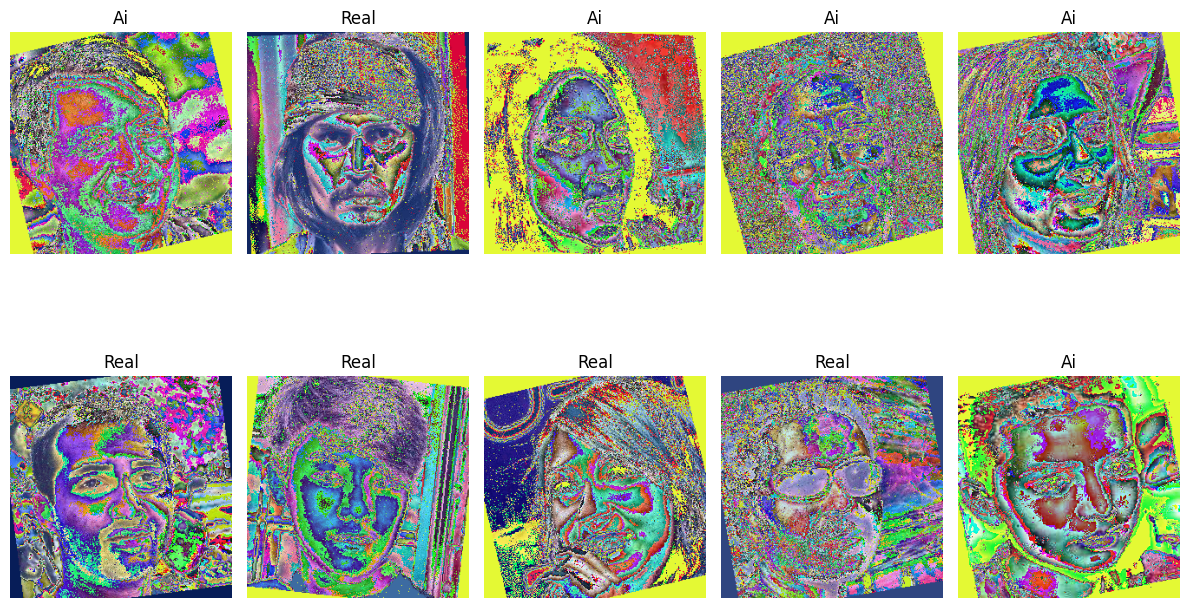

In [13]:
to_pil = transforms.ToPILImage()


def show_image(img):
    image = to_pil(img)
    plt.imshow(image)
    plt.axis("off")
    
    
dataiter = iter(train_loader)
_images, _labels = next(dataiter)
plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    show_image(_images[i])
    plt.title("Real" if _labels[i].item() == 0 else "Ai")
    
plt.tight_layout()
plt.show()

# **MODEL MODULE**

In [14]:
class DeepBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c)
        )
        self.shortcut = nn.Sequential()
        if in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, bias=False),
                nn.BatchNorm2d(out_c)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv(x) + self.shortcut(x))


class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = DeepBlock(3, 32)
        self.layer2 = DeepBlock(32, 64)
        self.layer3 = DeepBlock(64, 128)
        self.layer4 = DeepBlock(128, 256)
        self.layer5 = DeepBlock(256, 512) 

        self.pool = nn.AvgPool2d(2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        x = self.pool(self.layer1(x))
        x = self.pool(self.layer2(x))
        x = self.pool(self.layer3(x))
        x = self.pool(self.layer4(x))
        x = self.pool(self.layer5(x))
        x = self.global_pool(x)
        return self.classifier(x)
        
    def show_summary(self):
        summary(self, input_size=(3, 256, 256))
        return

# **MODEL**

In [15]:
MODEL = Model().to(DEVICE)
OPTIMIZER = optim.AdamW(
    MODEL.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-2
)

# MODEL

In [16]:
MODEL.show_summary()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             864
       BatchNorm2d-2         [-1, 32, 256, 256]              64
              ReLU-3         [-1, 32, 256, 256]               0
            Conv2d-4         [-1, 32, 256, 256]           9,216
       BatchNorm2d-5         [-1, 32, 256, 256]              64
            Conv2d-6         [-1, 32, 256, 256]              96
       BatchNorm2d-7         [-1, 32, 256, 256]              64
              ReLU-8         [-1, 32, 256, 256]               0
         DeepBlock-9         [-1, 32, 256, 256]               0
        AvgPool2d-10         [-1, 32, 128, 128]               0
           Conv2d-11         [-1, 64, 128, 128]          18,432
      BatchNorm2d-12         [-1, 64, 128, 128]             128
             ReLU-13         [-1, 64, 128, 128]               0
           Conv2d-14         [-1, 64, 1

In [17]:
if torch.cuda.device_count() > 1:
    print("Using two cuda devices.")
    MODEL = nn.DataParallel(MODEL)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    OPTIMIZER,
    mode="max",  # max т.к. нам надо получить максимальный f1-score 
    factor=0.3,
    patience=2
)

Using two cuda devices.


# **PLOTS MODULE**

In [18]:
def show_losses(
        train_losses,
        val_losses,
        val_F1Scores
):
    clear_output()

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(val_F1Scores, label="Val F1-Score")
    plt.xlabel("Epoch")
    plt.ylabel("F1-Score")
    plt.legend()
    plt.title("F1-Score curve")

    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss curves")

    plt.tight_layout()
    plt.show()

# **TRAIN MODULE**

In [19]:
def get_threshold(probs, labels):
    best_thr = 0
    best_f1 = 0
    for th in np.arange(0.1, 0.9, 0.01):
        preds = probs > th
        f1 = f1_score(labels.cpu().numpy(), preds.int().cpu().numpy())
        if f1 > best_f1:
            best_thr = th
            best_f1 = f1
    return best_thr, best_f1

In [20]:
def train(
        model,
        loader,
        optimizer
):
    model.train()
    total_loss = 0
    for images, labels in loader: # tqdm(loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        outputs = model(images)
        loss = criterion(outputs, labels.float())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_loss = total_loss / len(loader)
    return avg_loss


@torch.no_grad()
def evaluate(
        model,
        loader
):
    model.eval()
    total_loss = 0
    
    all_probs = []
    all_labels = []
    for image, labels in loader: # tqdm(loader):
        image, labels = image.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        outputs = model(image)
        probs = torch.sigmoid(outputs)
        
        loss = criterion(outputs, labels.float())
        total_loss += loss.item()
        
        all_probs.extend(probs)
        all_labels.extend(labels)
        
    avg_loss = total_loss / len(loader)
    th, F1_score = get_threshold(
        torch.tensor(all_probs),
        torch.tensor(all_labels)
    )
    
    return avg_loss, F1_score, th

# **RUN_TRAINING MODULE**

In [21]:
def run(
        model,
        _train_loader,
        _val_loader,
        optimizer,
        epochs: int
):
    train_losses = []
    val_losses = []
    val_F1Scores = []
    
    best_th = 0.
    best_epoch, best_F1 = -1, 0

    for epoch in range(epochs):
        train_loss = train(
            model,
            _train_loader,
            optimizer
        )
        val_loss, val_F1, th = evaluate(
            model,
            _val_loader
        )
        scheduler.step(val_F1)
        
        if val_F1 > best_F1:
            best_epoch = epoch
            best_th = th
            best_F1 = val_F1
            
            if best_F1 >= 0.95:
                torch.save(MODEL.state_dict(), MODEL_WEIGHTS_PATH)
            
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_F1Scores.append(val_F1)
        
        show_losses(
            train_losses=train_losses,
            val_losses=val_losses,
            val_F1Scores=val_F1Scores
        )
        print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1-Score: {val_F1:.4f}")
        print(f"Learning Rate: {LEARNING_RATE}")
        print(f"Best F1-Score: {best_F1:.4f} | Threshold: {best_th:.2f} | Epoch {best_epoch + 1}")
        
    return {
        "th": best_th,
        "f1": best_F1
    }

# **TRAINING**

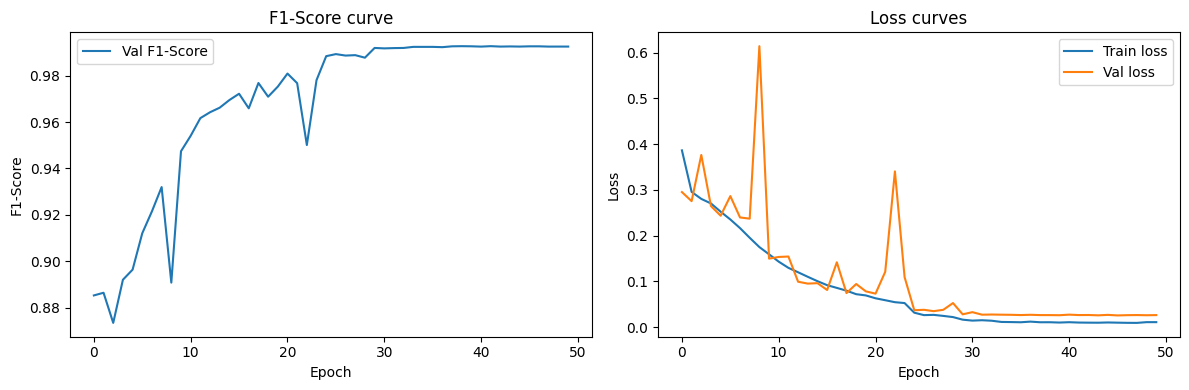

Epoch 50/50 | Train Loss: 0.0108 | Val Loss: 0.0262 | Val F1-Score: 0.9926
Learning Rate: 0.001
Best F1-Score: 0.9927 | Threshold: 0.51 | Epoch 42


In [22]:
train_result = run(
    model=MODEL,
    _train_loader=train_loader,
    _val_loader=val_loader,
    optimizer=OPTIMIZER,
    epochs=EPOCHS
)

# **LOADING MODEL WEIGHTS**

In [23]:
MODEL.load_state_dict(torch.load(MODEL_WEIGHTS_PATH))

<All keys matched successfully>

# **TEST_DATASET MODULE**

In [24]:
all_test_data = load_all_data(
    root_dir=TEST_IMAGES_DIR
)

test_dataset = CustomDataset(
    data=all_test_data,
    _transform=base_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    prefetch_factor=2
)

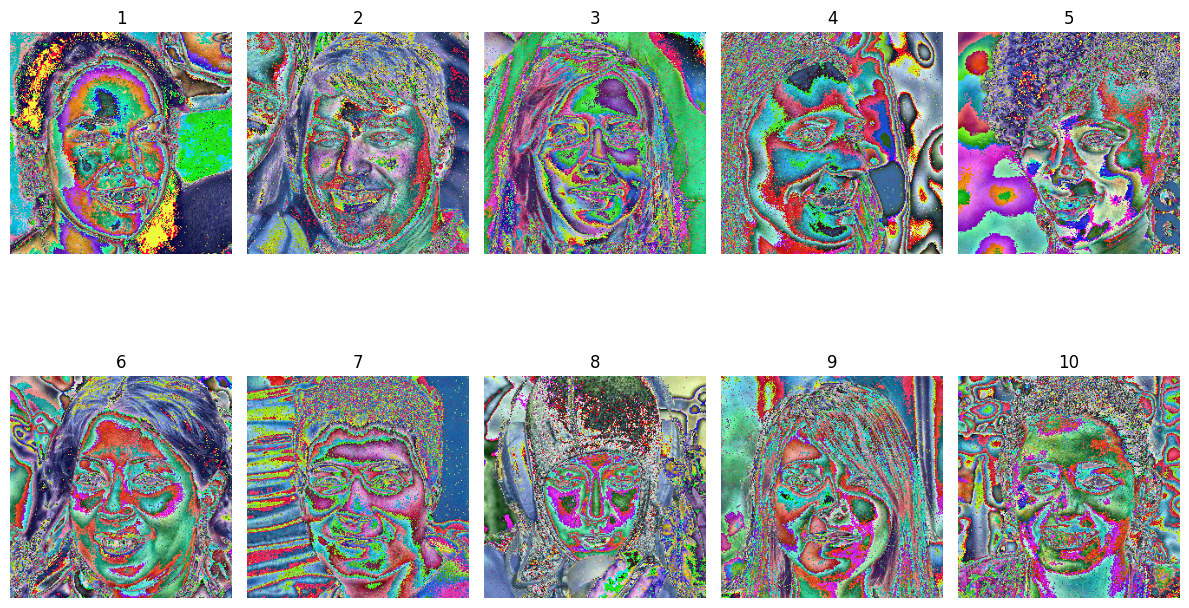

In [25]:
to_pil = transforms.ToPILImage()


def show_image(img):
    image = to_pil(img)
    plt.imshow(image)
    plt.axis("off")
    
    
dataiter = iter(test_loader)
_images, _labels = next(dataiter)
plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    show_image(_images[i])
    plt.title(_labels[i].item() + 1)
    
plt.tight_layout()
plt.show()

# **PREDICT MODULE**

In [26]:
@torch.no_grad()
def predict(
        model,
        loader, 
        th
):
    model.eval()

    result_predictions = []

    for images, images_ids in loader:
        images = images.to(DEVICE)

        outputs = model(images)
        probs = outputs.squeeze()

        preds = (probs > th).int().cpu().numpy()     
        
        for img_id, pred in zip(images_ids, preds):
            result_predictions.append(
                (img_id.item(), pred)
            )

    return result_predictions

# **PREDICT**

In [27]:
test_predictions = predict(
    MODEL,
    test_loader,
    train_result["th"]
)

In [28]:
df = pd.DataFrame(test_predictions, columns=["id", "target_feature"])
df = df.sort_values("id")
df.to_csv(SUBMISSION_FILE_PATH, index=False)